In [2]:
# -- used librarys
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from scipy import stats

from IPython.display import display

from oemof.demand import bdew

import datetime

import pvlib
from pvlib.modelchain import ModelChain as Mc_Pva
from pvlib.location import Location 
from pvlib.pvsystem import PVSystem
from pvlib.solarposition import get_solarposition
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

import pyomo.environ as pyo
from pyomo.opt import SolverFactory

## Load profile generation

In [3]:
# -- load profile
# demand
E_el_total = 1e12 # 1 TWh #################################################################################################################
E_el_commercial = 0.45 * E_el_total # = 0.45 TWh #################################################################################################################
E_el_agriculture = 0.15 * E_el_total # = 0.15 TWh #################################################################################################################
E_el_households = 0.4 * E_el_total # = 0.4 TWh #################################################################################################################

# load profiles
dict_demand_year = {}

for year in range(2020, 2050):
    holidays = {
        datetime.date(year, 1, 1): "New Year's Day",
        datetime.date(year, 4, 10): "Good Friday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 4, 13): "Easter Monday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 5, 1): "Labour Day",
        datetime.date(year, 5, 21): "Ascension Day", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 6, 1): "Whit Monday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 10, 3): "German Unity Day",
        datetime.date(year, 12, 25): "Christmas Day",
        datetime.date(year, 12, 26): "Boxing Day",
    } # for variance in load profile

    e_slp = bdew.ElecSlp(year, holidays=holidays)
    df_load_commercial = e_slp.get_scaled_power_profiles({"g0": E_el_commercial})
    df_load_agriculture = e_slp.get_scaled_power_profiles({"l0": E_el_agriculture})
    df_load_households = e_slp.get_scaled_power_profiles({"h0": E_el_households})
    dict_demand_year[year] = (df_load_commercial["g0"] + df_load_agriculture["l0"] + df_load_households["h0"]).resample('1h').mean()

series_load = pd.concat(dict_demand_year.values())

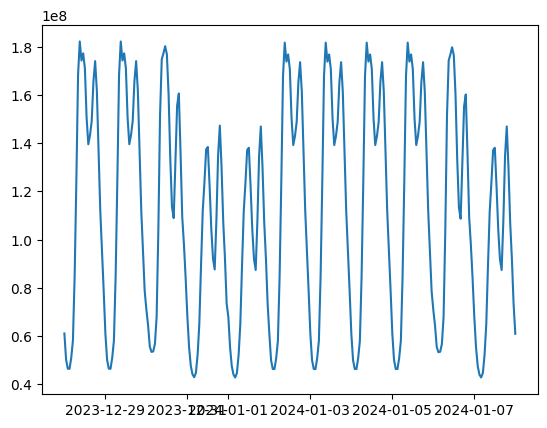

In [4]:
# Hier noch Lastgänge visualisieren
plt.plot(series_load["2023-12-28 00:00:00":"2024-01-08 00:00:00"])

## Weather data import

In [5]:
# -- meta data
# north
df_meta_north = pd.read_csv("./Nord 00591/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_north = float(df_meta_north.iloc[-1,4])
latlon_north = [float(df_meta_north.iloc[-1,3]), float(df_meta_north.iloc[-1,2])]
# south
df_meta_south = pd.read_csv("./Süd 05404/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_south = float(df_meta_south.iloc[-1,4]) 
latlon_south = [float(df_meta_south.iloc[-1,3]), float(df_meta_south.iloc[-1,2])]
# center
df_meta_center = pd.read_csv("./Zentrum 03231/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_center = float(df_meta_center.iloc[-1,4]) 
latlon_center = [float(df_meta_center.iloc[-1,3]), float(df_meta_center.iloc[-1,2])]

# list with meta data
list_latlons = [latlon_north, latlon_south, latlon_center]
list_heights_station = [height_station_north, height_station_south, height_station_center]

In [6]:
# -- weather data set north
# import data for irradiance in J/(cm^2)
df_solar_north = pd.read_csv("./Nord 00591/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_north = df_solar_north.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_north = pd.read_csv("./Nord 00591/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_north = df_temperature_north.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_north = df_solar_north.join(df_temperature_north, how="outer")

In [7]:
# -- weather data set south
# import data for irradiance in J/(cm^2)
df_solar_south = pd.read_csv("./Süd 05404/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_south = df_solar_south.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_south = pd.read_csv("./Süd 05404/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_south = df_temperature_south.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_south = df_solar_south.join(df_temperature_south, how="outer")

In [8]:
# -- weather data set center
# import data for irradiance in J/(cm^2)
df_solar_center = pd.read_csv("./Zentrum 03231/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_center = df_solar_center.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_center = pd.read_csv("./Zentrum 03231/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_center = df_temperature_center.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_center = df_solar_center.join(df_temperature_center, how="outer")

In [9]:
# -- data cleaning - replacing error value -999 with average value at the same time of other years
dict_error = {}
list_str_location = ["North", "South", "Center"]
indexdiff_one_year = 6 * 24 * 365 # number of indices per year - leap year neglected, since shift of 10 minutes has only small influence
list_df_location = [df_north, df_south, df_center] # temporary list for iteration, will be overwritten at the end of the loop
list_years = ["2020", "2021", "2022", "2023", "2024"] # cleaning for each year, based on the other years ########################################################################### 2024 COULD BE DELETED
list_colnames = df_north.columns.astype(str)[1:] # north is used here, but the column names apply to all stations
for i, df_location in enumerate(list_df_location): # iteration through all location
    dict_error_measurement = {}
    for measurement in list_colnames: # iteration through all measured values (solar - global and diffuse irradiance, temperature, pressure)
        counter_error_measurement = 0
        for index in range(df_location.shape[0]): # for each index (i.e. each timestamp)
            if df_location.loc[index, measurement] == -999: # all entries that have error value -999
                counter_error_measurement += 1
                year_diff = 0 # correction value that sets the comparison years relative to the current year
                for year in list_years: 
                    if str(df_location.iloc[index, 0])[:4] == year: # filter to the respective year for specific application
                        list_compare_value = [] # comparison values at the same time from the other years are inserted here
                        list_manipulated_compare_factors = [(0-year_diff), (1-year_diff), (2-year_diff), (3-year_diff), (4-year_diff)] # i.e. in 2022: [-2, -1, 0, 1, 2]
                        for compare_factor in list_manipulated_compare_factors: # numbers in list represent annual distance, e.g. -1 => 1 year in the past, 2 => 2 years in the future
                            if df_location.loc[(index + indexdiff_one_year * compare_factor), measurement] != -999: # filtering comparison values without error value
                                list_compare_value.append(df_location.loc[(index + indexdiff_one_year * compare_factor), measurement])
                        df_location.loc[index, measurement] = np.mean(list_compare_value) # replace error value with average of comparison values
                    year_diff += 1
        dict_error_measurement[measurement] = counter_error_measurement
    dict_error[list_str_location[i]] = dict_error_measurement
    # renaming 
    df_location["MESS_DATUM"] = pd.to_datetime(df_location["MESS_DATUM"], format="%Y%m%d%H%M") # read timestamp correctly
    df_location = df_location.rename(
        columns={"DS_10": "dhi", "GS_10": "ghi", "TT_10": "temp_air", "PP_10": "pressure"}
    )
    df_location = df_location.set_index("MESS_DATUM")
    df_location.index.name = None
    # units
    df_location["ghi"] *= (10000 / 600) # Conversion factor from J/(cm² * 10min) to avg W/(m²)
    df_location["dhi"] *= (10000 / 600) # Conversion factor from J/(cm² * 10min) to avg W/(m²)
    df_location["pressure"] *= 100 # Conversion factor hPa to Pa
    df_location["Ø global irradiance [kWh/(m²a)]"] = df_location["ghi"] * 8.76 # Conversion factor from W/(m²) to kWh/(m²a)
    # reduce data set to 4 years (to be able to repeat the data periodically with respect to the leap year) and resample data on hours
    df_location = df_location.resample("h").mean()
    df_location = df_location.loc[:"2023-12-31 23:00:00"]
    # overwrites the element in the list that stores the data frames
    list_df_location[i] = df_location

# vizualisation for missing values in the weather data sets    
df_error = pd.DataFrame(dict_error)
df_error = df_error.rename(index={
    "DS_10": "diffuse horizontal irradiance",
    "GS_10": "global horizontal irradiance",
    "PP_10": "ambient pressure",
    "TT_10": "temperature at 2 m AGL" # above ground level
})
df_error.index.name = "missing values in data set (5 years)"
display(df_error)

,North,South,Center
missing values in data set (5 years),,,
diffuse horizontal irradiance,604,6909,505
global horizontal irradiance,604,2447,505
ambient pressure,44,475,322
temperature at 2 m AGL,64,588,0


In [10]:
# -- checking for missing values for certainty (as comment, so that process doen't need to be done in every run)
# for i, df in enumerate(list_df_location):
#     for index in range(len(df)):
#         for measurement in range(5):
#             if df.iloc[index, measurement] < -20:
#                 print(i, index, measurement, df.iloc[index, measurement])

In [11]:
# -- 4 year average of the weather data
dict_weather_mean = {}
list_weather_columns = []

for i, df in enumerate(list_df_location):
    dict_colnames_weather_temp = {}
    list_weather_columns = [colname for colname in df.columns]
    for colname in df.columns:
        dict_colnames_weather_temp[colname] = float(round(df[colname].mean(), 2))
    dict_weather_mean[list_str_location[i]] = dict_colnames_weather_temp
    
df_weather_mean = pd.DataFrame(data=dict_weather_mean)
df_weather_mean = df_weather_mean.rename(index={
    "dhi": "Ø diffuse irradiance [W/m²]", 
    "ghi": "Ø global irradiance [W/m²]",
    "pressure": "Ø ambient pressure [Pa]",
    "Ø global irradiance [kWh/(m²a)]": "Ø global irradiance energy [kWh/(m²a)]",
	"temp_air": "Ø ambient pressure [°C]"
}).sort_index()

series_heights_station = pd.Series(list_heights_station, name="station height [m]", index=df_weather_mean.columns)
df_weather_mean = pd.concat((df_weather_mean.T, series_heights_station), axis=1).T

df_weather_mean

,North,South,Center
Ø ambient pressure [Pa],100964.62,96123.47,96347.65
Ø ambient pressure [°C],10.47,9.70,9.25
Ø diffuse irradiance [W/m²],62.42,58.59,61.74
Ø global irradiance [W/m²],126.71,146.03,126.32
Ø global irradiance energy [kWh/(m²a)],1109.99,1279.25,1106.52
station height [m],44.72,477.10,450.00


In [12]:
# -- model for calculating PV array generation data
dict_pva = {}
list_module_choice = ["Canadian_Solar_CS5P_220M___2009_", "Schott_Solar_ASE_270_DGF_50__260___2007__E__"] 
# create system for calculation
sandia_modules = pvlib.pvsystem.retrieve_sam("SandiaMod") # database for solar modules
cec_inverters = pvlib.pvsystem.retrieve_sam("CECInverter") # database for inverters
module = sandia_modules[list_module_choice[0]] # reference constellation 0: "Canadian_Solar_CS5P_220M___2009_"
inverter = cec_inverters["ABB__MICRO_0_25_I_OUTD_US_208__208V_"] 
temperature_parameters = TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"]
all_min_temps = [df["temp_air"].min() for df in list_df_location]
min_temperature = min(all_min_temps) # -18.1
# system
system_pva = PVSystem(
    surface_tilt=30, 
    surface_azimuth=180, 
    module_parameters=module, 
    inverter_parameters=inverter, 
    temperature_model_parameters=temperature_parameters,
    modules_per_string=1,
    strings_per_inverter=1
)
# assign a location and a model chain to each station based on its metadata, used to calculate generation data
list_locations = []
for i, df in enumerate(list_df_location): # i is an index, where 0=north, 1=south, 2=center
    latitude = list_latlons[i][0]
    longitude = list_latlons[i][1]
    altitude = list_heights_station[i]
    location = Location(
        latitude=latitude, 
        longitude=longitude,
        altitude=altitude,
        tz="Europe/Berlin"
    )
    list_locations.append(location)
    modelchain_pva = Mc_Pva(
        system=system_pva, 
        location=location,
        aoi_model="sapm",
        spectral_model="sapm",
        losses_model="pvwatts"
    )
    print(modelchain_pva.system.pvwatts_losses())
    # calculate direct normal irradiance (dni) from global horizontal irradiance (ghi), diffuse horizontal irradiance (dhi) and solar zenith
    solpos = get_solarposition(
        time=df.index, 
        latitude=latitude, 
        longitude=longitude,
        altitude=altitude
        ) # calculate solar position
    dni = pvlib.irradiance.dirint(
        ghi=df["ghi"],
        solar_zenith=solpos["zenith"],
        times=df.index,
        pressure=df["pressure"],
    ) # ghi = dhi + dni * cos(theta)
    df["dni"] = dni.clip(lower=0)
    # run model chains and save results
    modelchain_pva.run_model(df) # run model chain for respective dataframe - uses columns temp_air, ghi, dni and dhi
    scaling_factor_pva = 1_000_000 / (module["Impo"] * module["Vmpo"])
    ac = modelchain_pva.results.ac.copy()
    ac = ac.clip(lower=0).fillna(0)
    P_pva_scalable = ac * scaling_factor_pva # scaled to 1,000,000 W (1 MW)
    list_df_location[i]["P_pva_scalable"] = P_pva_scalable # save results in dict
    # for visualization only
    ac = ac
    dc = modelchain_pva.results.dc.p_mp.clip(lower=0).fillna(0)
    dc_power = (dc * scaling_factor_pva).mean() 
    inverter_efficiency_weighted_percent = (ac.mean() / dc.mean()) * 100
    inverter_efficiency_unweighted_percent = (ac / dc).mean() * 100
    effective_irradiance = modelchain_pva.results.total_irrad["poa_global"].fillna(0).mean()
    dict_pva_temp = {
        "Ø DC-power [kW]": (dc_power / 1_000), 
        "Ø AC-power [kW]": (P_pva_scalable.mean() / 1_000),
        "Ø inverter efficiency (weighted) [%]": inverter_efficiency_weighted_percent, 
        "Ø inverter efficiency (not weighted) [%]": inverter_efficiency_unweighted_percent, 
        "Ø global irradiance POA [W/m²]": effective_irradiance, # POA = plane of array
        "Ø full load hours [h/a]": ((P_pva_scalable.mean() / 1_000_000 ) * 8760)
    }
    dict_pva[list_str_location[i]] = dict_pva_temp
df_pva = pd.DataFrame(dict_pva)
display(df_pva.round(2))

14.075660688264469
14.075660688264469
14.075660688264469


,North,South,Center
Ø DC-power [kW],113.99,123.33,108.21
Ø AC-power [kW],107.15,116.19,101.61
Ø inverter efficiency (weighted) [%],94.00,94.21,93.90
Ø inverter efficiency (not weighted) [%],79.13,81.55,77.77
Ø global irradiance POA [W/m²],145.32,156.95,137.04
Ø full load hours [h/a],938.64,1017.86,890.08


In [13]:
# -- periodally repeat data frame to have 30 years (life span of pv-system in frauenhofer calculation)
for i, df in enumerate(list_df_location):
    if df.index[-1].year == 2023:
        df = pd.concat(([df] * 7) + [df.loc[:"2021-12-31 23:00:00"]]) # overall 4 years times 7.5 = 30 years
        df.index = pd.date_range(start="2020-01-01", periods=len(df), freq="h")
        list_df_location[i] = df
list_df_location[0].loc["2023-12-31 20:00:00":"2024-01-01 03:00:00"]

,dhi,ghi,pressure,temp_air,Ø global irradiance [kWh/(m²a)],dni,P_pva_scalable
2023-12-31 20:00:00,0.0,0.0,99496.666667,6.683333,0.0,NaN,0.0
2023-12-31 21:00:00,0.0,0.0,99515.000000,6.233333,0.0,NaN,0.0
2023-12-31 22:00:00,0.0,0.0,99503.333333,5.233333,0.0,NaN,0.0
2023-12-31 23:00:00,0.0,0.0,99508.333333,4.850000,0.0,NaN,0.0
2024-01-01 00:00:00,0.0,0.0,102826.666667,1.700000,0.0,NaN,0.0
2024-01-01 01:00:00,0.0,0.0,102805.000000,1.416667,0.0,NaN,0.0
2024-01-01 02:00:00,0.0,0.0,102805.000000,1.633333,0.0,NaN,0.0
2024-01-01 03:00:00,0.0,0.0,102761.666667,1.533333,0.0,NaN,0.0


In [14]:
# -- define dicts that store the results for multiple optimization processes
dict_results_overview = {}
dict_results_NPV = {}

In [ ]:
# -- Assumptions
def lin_interp_extrap(x_new, x, y):
    n = - (y[-1] - y[0]) / (x[-1] - x[0]) * x[-1] + y[-1]
    y_new = (y[-1] - y[0]) / (x[-1] - x[0]) * x_new + n
    return y_new

# - dataFrame for optimization
i = 2 # 0:"north", 1:"south", 2:"center"
df_solve = list_df_location[i]

# - cost PVA
# 950 kWh/(m²a): ~ 6,2 ct/kWh; 1120 kWh/(m²a): ~ 5,7 ct/kWh
x_pva_1 = [950, 1120] # FLH
y_pva_1 = [0.062, 0.057] # LCOE
# 1120 kWh/(m²a): ~ 5,7 ct/kWh; 1300 kWh/(m²a): ~ 4,5 ct/kWh
x_pva_2 = [1120, 1300] # FLH
y_pva_2 = [0.057, 0.045] # LCOE 
# LCOE calculation
irr_pva = df_weather_mean.loc["Ø global irradiance energy [kWh/(m²a)]", list_str_location[i]]
if irr_pva < x_pva_1[1]:
    LCOE_pva = lin_interp_extrap(irr_pva, x_pva_1, y_pva_1)
else:
    LCOE_pva = lin_interp_extrap(irr_pva, x_pva_2, y_pva_2)
print("Ø global irradiance [kWh/(m²a)]:", irr_pva, "LCOE:", LCOE_pva.round(4))

# - cost battery
cost_bat = 464 # €/kWh, cost for capacity ~1-10 MWh
cost_bat_with_exchange = cost_bat * 1.3 # Frauenhofer: batterie exchange cost = 30 % of first investment (interest respected)

# - factors
WACC_pva = 0.035
factor_conv = 1 / 1000 # conversion Wh to kWh
factor_discount = (1 / (1 + WACC_pva))
factor_bat_EPR = 2 # energy power ratio, 2 h to fully charge or discharge
factor_bat_eff = 0.90 ** 0.5 # 90% efficiency of battery, symmetrical distribution for charging and discharging
count_timestemps_year = len(list_df_location[0]) / 5
print(count_timestemps_year)

Ø global irradiance [kWh/(m²a)]: 1106.52 LCOE: 0.0574
52598.4


In [16]:
# -- optimization model including battery sizing
model = pyo.ConcreteModel()

list_time = list(df_solve.index) # total time period

dict_time = {t: (i + 1) for i, t in enumerate(list_time)}
prev_t = {list_time[i]: list_time[i-1] for i in range(1, len(list_time))} # access to previous timestep (t-1)

# - parameters
# set of all timesteps
model.T = pyo.Set(initialize=list_time)
# index of timesteps (important for discounting)
model.t_index = pyo.Param(model.T, initialize=dict_time)
# PV power
model.P_pva = pyo.Param(model.T, initialize=df_solve["P_pva_scalable"])
# load profile
model.P_demand = pyo.Param(model.T, initialize=series_load)

# - variables
# PV array scaling factor (e.g. at 2 = 2 MWp PVA)
model.x_pva = pyo.Var(domain=pyo.NonNegativeReals)
# battery capacity (maximum storable energy)
model.E_bat_max = pyo.Var(domain=pyo.NonNegativeReals) 
# currently stored energy in battery
model.E_bat = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# current charging power of battery
model.P_bat_charge = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# current discharging power of battery
model.P_bat_discharge = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# lost energy that is neither fed in nor storable in battery
model.loss = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# - objective
# minimize cost
def objective_func(model):    
    cost_pva = sum(
        model.P_pva[t] 
        * (factor_discount ** (model.t_index[t] / count_timestemps_year)) # continuous discounting in hourly steps
        for t in model.T
    ) * model.x_pva * LCOE_pva * factor_conv # discounted PV array costs kWh*€/kWh
    
    cost_battery = model.E_bat_max * cost_bat_with_exchange # discounted battery capacity costs kWh*€/kWh
    
    return cost_pva + cost_battery  
model.objective = pyo.Objective(rule=objective_func, sense=pyo.minimize)

# - constraints
# ensure demand is covered by pv or stored energy, losses are allowed
def c_cover_demand(model, t):
    return (
        model.P_demand[t] == ( 
            model.P_pva[t] * model.x_pva
            + model.P_bat_discharge[t] 
            - model.P_bat_charge[t] 
            - model.loss[t]
        )
    )
model.c_cover_demand = pyo.Constraint(model.T, rule=c_cover_demand)
# limit battery discharge power
def c_battery_discharge_limit(model, t): 
    return model.P_bat_discharge[t] * factor_bat_EPR <= model.E_bat_max * 1_000 # discharge power relative to capacity: 2
model.c_battery_discharge_limit = pyo.Constraint(model.T, rule=c_battery_discharge_limit) 
# limit battery charge power
def c_battery_charge_limit(model, t): 
    return model.P_bat_charge[t] * factor_bat_EPR <= model.E_bat_max * 1_000 # charge power relative to capacity: 2
model.c_battery_charge_limit = pyo.Constraint(model.T, rule=c_battery_charge_limit) 
# limit battery capacity
def c_battery_capacity_limit(model, t): 
    return model.E_bat[t] <= model.E_bat_max 
model.c_battery_capacity_limit = pyo.Constraint(model.T, rule=c_battery_capacity_limit) 
# define current battery state of charge
def c_battery_energy (model, t): 
    if t == list_time[0]: 
        return model.E_bat[t] == 0.1 * model.E_bat_max  
    else: 
        return model.E_bat[t] == ( 
            model.E_bat[prev_t[t]]  
            + ( 
                model.P_bat_charge[prev_t[t]] * factor_bat_eff 
                - model.P_bat_discharge[prev_t[t]] * (1 / factor_bat_eff) 
            ) * factor_conv 
        ) # with factor_conv therefore model.E_bat(_max) with unit kWh
model.c_battery_energy = pyo.Constraint(model.T, rule=c_battery_energy) 
# define periodic boundary condition for stored energy 
def c_bat_cyclic (model): 
    return model.E_bat[list_time[-1]] == model.E_bat[list_time[0]]
model.c_bat_cyclic = pyo.Constraint(rule=c_bat_cyclic)

# solving and saving results
opt = SolverFactory("cbc", executable="./CBC/bin/cbc.exe")

results = opt.solve(model, keepfiles=False, logfile="solve.log")

In [17]:
df_result = pd.DataFrame({
    "E_bat": [pyo.value(model.E_bat[t]) for t in model.T], 
    "P_bat": [pyo.value(model.P_bat_discharge[t]) - pyo.value(model.P_bat_charge[t]) for t in model.T], 
    "P_demand": [pyo.value(model.P_demand[t]) for t in model.T],
    "loss": [pyo.value(model.loss[t]) for t in model.T]
}, index=model.T).join([
    df_solve["P_pva_scalable"] * pyo.value(model.x_pva)
]).rename(columns={"P_pva_scalable": "P_pva_model"}) 

dict_results_overview_temp = {
    "Rated power PVA [GW]": float(round(pyo.value(model.x_pva) / 1e3, 3)),
    "Capacity battery [GWh]": float(round(pyo.value(model.E_bat_max) / 1e6, 3)), 
    "Demand [TWh]": df_result["P_demand"].sum() / 1e12,
    "LCOE PVA [ct/kWh]": round(LCOE_pva * 100, 3),
    "Total cost [Million €]": float(round(pyo.value(model.objective) / 1e6, 3)), 
    "Unused energy (loss) [TWh]": df_result["loss"].sum() / 1e12
}
dict_results_overview[list_str_location[i]] = dict_results_overview_temp
df_results_overview = pd.DataFrame(dict_results_overview)
display(df_results_overview.round(2))

,Center
Rated power PVA [GW],7.75
Capacity battery [GWh],35.49
Demand [TWh],30.00
LCOE PVA [ct/kWh],5.74
Total cost [Million €],32330.66
Unused energy (loss) [TWh],175.42


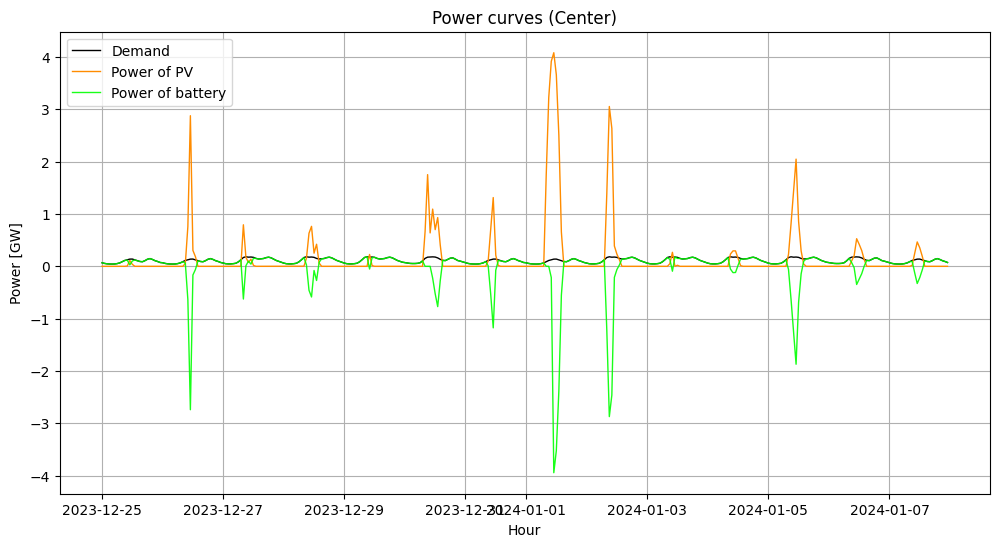

In [18]:
# -- Visualisierung der Modellausgaben
df_result_for_visualization = df_result.loc[
    "2023-12-25":"2024-01-07", ("P_pva_model", "P_bat", "P_demand", "loss") # "2020-06-01 00:00:00":"2020-06-12 23:50:00"
    ]#.resample("D").mean()
# df_result_for_visualization = df_result_for_visualization.groupby(df_result_for_visualization.index.time).mean()

x = df_result_for_visualization.index #[t.hour + t.minute / 60 for t in df_result_for_visualization.index] #
y_demand = df_result_for_visualization["P_demand"] / 1e9
y_pva = df_result_for_visualization["P_pva_model"] / 1e9
y_bat = df_result_for_visualization["P_bat"] / 1e9
y_loss = df_result_for_visualization["loss"] / 1e9
y_sum = y_pva - y_loss + y_bat 

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(x, y_demand, label="Demand", linewidth=1, color="black", alpha=1)
ax1.plot(x, y_pva, label="Power of PV", linewidth=1, color="darkorange", alpha=1)
ax1.plot(x, y_bat, label="Power of battery", linewidth=1, color="lime", alpha=0.9) 
ax1.set_ylabel("Power [GW]")
ax1.set_xlabel("Hour") ######### Year
ax1.legend(loc="upper left")

# ax1.set_xticks([0, 4, 8, 12, 16, 20, 24]) #########

plt.grid(True)

plt.title(f"Power curves ({list_str_location[i]})")
plt.show()